# PySUS
Biblioteca Python para abstrair a manipulação dos dados à partir do sistema de FTP do DATASUS FTP, sendo disponibilizados os datasets:

- CNES - Cadastro Nacional de Estabelecimentos de Saúde
- SINAN - Doenças e Agravos de Notificação
- SINASC - Sistema de Informações sobre Nascidos Vivos
- SIM - Sistema de Informação sobre Mortalidade
- SIA - Sistema de Informações Ambulatoriais
- SIH - Sistema de Informações Hospitalares

O PySUS mantém uma documentação que pode ser consultada no seguinte link: https://pysus.readthedocs.io/

# 0.0 - Importação de Bibliotecas

In [18]:
from pathlib import Path
import pandas as pd 
from pysus import SIA
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1.0 - Aquisição de Dados

# Sistema de Informações Ambulatoriais
## Fonte
http://sia.datasus.gov.br/principal/index.php

## Descrição
O Sistema de Informação Ambulatorial (SIA) foi instituído pela Portaria GM/MS n.º 896 de 29 de junho de 1990. 
Originalmente, o SIA foi concebido a partir do projeto SICAPS (Sistema de Informação e Controle Ambulatorial da Previdência Social), em que os conceitos, os objetivos e as diretrizes criados para o desenvolvimento do SICAPS foram extremamente importantes e amplamente utilizados para o desenvolvimento do SIA, tais como: 

1. O acompanhamento das programações físicas e orçamentárias; 
2. O acompanhamento das ações de saúde produzidas; 
3. A agilização do pagamento e controle orçamentário e financeiro; 
4. A formação de banco de dados para contribuir com a construção do SUS.

## Conjuntos de Dados

1. 'AB': 'APAC de Cirurgia Bariátrica',
2. 'ABO': 'APAC de Acompanhamento Pós Cirurgia Bariátrica',
3. 'ACF': 'APAC de Confecção de Fístula',
4. 'AD': 'APAC de Laudos Diversos',
5. 'AM': 'APAC de Medicamentos',
6. 'AMP': 'APAC de Acompanhamento Multiprofissional',
7. 'AN': 'APAC de Nefrologia',
8. 'AQ': 'APAC de Quimioterapia',
9. 'AR': 'APAC de Radioterapia',
10. 'ATD': 'APAC de Tratamento Dialítico',
11. 'BI': 'Boletim de Produção Ambulatorial individualizado',
12. 'IMPBO': '',
13. 'PA': 'Produção Ambulatorial',
14. 'PAM': '',
15. 'PAR': '',
16. 'PAS': '',
17. 'PS': 'RAAS Psicossocial',
18. 'SAD': 'RAAS de Atenção Domiciliar'

* APAC: Autorização de Procedimentos Ambulatoriais de Alta Complexidade
* RAAS: Registro de Ações Ambulatoriais de Saúde

In [4]:
sia = SIA().load()
sia

SIA - Sistema de Informações Ambulatoriais

In [5]:
sia.metadata

{'long_name': 'Sistema de Informações Ambulatoriais',
 'source': 'http://sia.datasus.gov.br/principal/index.php',
 'description': 'O Sistema de Informação Ambulatorial (SIA) foi instituído pela Portaria GM/MS n.º 896 de 29 de junho de 1990. Originalmente, o SIA foi concebido a partir do projeto SICAPS (Sistema de Informação e Controle Ambulatorial da Previdência Social), em que os conceitos, os objetivos e as diretrizes criados para o desenvolvimento do SICAPS foram extremamente importantes e amplamente utilizados para o desenvolvimento do SIA, tais como: (i) o acompanhamento das programações físicas e orçamentárias; (ii) o acompanhamento das ações de saúde produzidas; (iii) a agilização do pagamento e controle orçamentário e financeiro; e (iv) a formação de banco de dados para contribuir com a construção do SUS.'}

In [6]:
sia.groups

{'AB': 'APAC de Cirurgia Bariátrica',
 'ABO': 'APAC de Acompanhamento Pós Cirurgia Bariátrica',
 'ACF': 'APAC de Confecção de Fístula',
 'AD': 'APAC de Laudos Diversos',
 'AM': 'APAC de Medicamentos',
 'AMP': 'APAC de Acompanhamento Multiprofissional',
 'AN': 'APAC de Nefrologia',
 'AQ': 'APAC de Quimioterapia',
 'AR': 'APAC de Radioterapia',
 'ATD': 'APAC de Tratamento Dialítico',
 'BI': 'Boletim de Produção Ambulatorial individualizado',
 'IMPBO': '',
 'PA': 'Produção Ambulatorial',
 'PAM': '',
 'PAR': '',
 'PAS': '',
 'PS': 'RAAS Psicossocial',
 'SAD': 'RAAS de Atenção Domiciliar'}

In [7]:
files = sia.get_files('BI', uf = 'PB', year=[2019, 2020, 2021])
len(files)

36

In [8]:
sia.describe(files[0])

{'name': 'BIPB1901.dbc',
 'group': 'Boletim de Produção Ambulatorial individualizado',
 'uf': 'Paraíba',
 'month': 'Janeiro',
 'year': 2019,
 'size': '14.3 MB',
 'last_update': '2020-04-16 07:52PM'}

In [9]:
sia.describe(files[-1])

{'name': 'BIPB2112.dbc',
 'group': 'Boletim de Produção Ambulatorial individualizado',
 'uf': 'Paraíba',
 'month': 'Dezembro',
 'year': 2021,
 'size': '13.1 MB',
 'last_update': '2023-10-12 03:01PM'}

In [10]:
for i, file_id in enumerate(files):
    sia.download([file_id], local_dir=str(data_dir))

14256643it [00:00, 6666298189.68it/s]
14620769it [00:00, 10719096294.31it/s]
16932885it [00:00, 10501503369.37it/s]
18512027it [00:00, 32830895938.35it/s]
19466021it [00:00, 37332606193.13it/s]
18392100it [00:00, 24844463316.71it/s]
21130452it [00:00, 35838066860.25it/s]
22418724it [00:00, 18638442764.74it/s]
21257633it [00:00, 29377586531.28it/s]
19865555it [00:00, 34359660535.55it/s]
18419698it [00:00, 42033630576.82it/s]
16365049it [00:00, 24288743977.67it/s]
15612568it [00:00, 31512924163.94it/s]
15701810it [00:00, 16209245505.84it/s]
12347094it [00:00, 31908481671.33it/s]
5386319it [00:00, 7718435028.01it/s] 
5764659it [00:00, 12023238340.30it/s]
7151343it [00:00, 15350515122.96it/s]
9684440it [00:00, 22516344473.26it/s]
10536372it [00:00, 15704601003.94it/s]
11716322it [00:00, 26335378472.61it/s]
15890592it [00:00, 23134319190.55it/s]
15995789it [00:00, 53162600464.23it/s]
11782984it [00:00, 27671566026.39it/s]
11921633it [00:00, 29834697481.16it/s]
13298579it [00:00, 35755309675

In [11]:
metadata = []

for f in files:
    describe = sia.describe(f)
    metadata.append(describe)


df_meta = pd.DataFrame(metadata)

In [12]:
df_meta.head()

,name,group,uf,month,year,size,last_update
0,BIPB1901.dbc,Boletim de Produção Ambulatorial individualizado,Paraíba,Janeiro,2019,14.3 MB,2020-04-16 07:52PM
1,BIPB1902.dbc,Boletim de Produção Ambulatorial individualizado,Paraíba,Fevereiro,2019,14.6 MB,2020-04-16 07:52PM
2,BIPB1903.dbc,Boletim de Produção Ambulatorial individualizado,Paraíba,Março,2019,16.9 MB,2020-07-06 02:12PM
3,BIPB1904.dbc,Boletim de Produção Ambulatorial individualizado,Paraíba,Abril,2019,18.5 MB,2020-07-06 02:12PM
4,BIPB1905.dbc,Boletim de Produção Ambulatorial individualizado,Paraíba,Maio,2019,19.5 MB,2020-07-06 02:12PM


# 2.0 Leitura de Dados

In [13]:
con = duckdb.connect('pysus.db')

con.execute("""
    CREATE OR REPLACE VIEW data AS 
    SELECT * FROM read_parquet('./data/**/*.parquet', hive_partitioning=True)
""")

resumo = con.execute("DESCRIBE data").fetchall()
num_colunas = len(resumo)
num_linhas = con.execute("SELECT count(*) FROM data").fetchone()[0]
print(f"Linhas:  {num_linhas:,}")
print(f"Colunas: {num_colunas}")

Linhas:  11,178,018
Colunas: 36


## 2.1 Metadata e Qualidade de Dados

In [14]:
df_describe = con.execute("DESCRIBE data").df()
print(df_describe)

   column_name column_type null   key default extra
0       CODUNI     VARCHAR  YES  None    None  None
1       GESTAO     VARCHAR  YES  None    None  None
2       CONDIC     VARCHAR  YES  None    None  None
3        UFMUN     VARCHAR  YES  None    None  None
4        TPUPS     VARCHAR  YES  None    None  None
5       TIPPRE     VARCHAR  YES  None    None  None
6       MN_IND     VARCHAR  YES  None    None  None
7      CNPJCPF     VARCHAR  YES  None    None  None
8      CNPJMNT     VARCHAR  YES  None    None  None
9      CNPJ_CC     VARCHAR  YES  None    None  None
10  DT_PROCESS     VARCHAR  YES  None    None  None
11    DT_ATEND     VARCHAR  YES  None    None  None
12     PROC_ID     VARCHAR  YES  None    None  None
13       TPFIN     VARCHAR  YES  None    None  None
14      SUBFIN     VARCHAR  YES  None    None  None
15     COMPLEX     VARCHAR  YES  None    None  None
16     AUTORIZ     VARCHAR  YES  None    None  None
17     CNSPROF     VARCHAR  YES  None    None  None
18     CBOPR

In [15]:
query = """
    SELECT 
        *
    FROM 
        data 
    LIMIT 
        5
"""
df = con.execute(query).df()
df

,CODUNI,GESTAO,CONDIC,UFMUN,TPUPS,TIPPRE,MN_IND,CNPJCPF,CNPJMNT,CNPJ_CC,DT_PROCESS,DT_ATEND,PROC_ID,TPFIN,SUBFIN,COMPLEX,AUTORIZ,CNSPROF,CBOPROF,CIDPRI,CATEND,CNS_PAC,DTNASC,TPIDADEPAC,IDADEPAC,SEXOPAC,RACACOR,MUNPAC,QT_APRES,QT_APROV,VL_APRES,VL_APROV,UFDIF,MNDIF,ETNIA,NAT_JUR
0,2399717,250750,PG,250750,07,00,M,08778268000594,08778268000160,00000000000000,201901,201901,0202010651,06,0000,2,0000000000000,980016285365089,223415,0000,02,{{}}{|,19720910,4,46,M,01,250890,1,1,2.01,2.01,0,1,,1023
1,2399741,250750,PG,250750,07,00,I,09112236000194,00000000000000,00000000000000,201901,201901,0301010072,06,0000,2,0000000000000,201561298030001,225121,C160,01,{{{~{}|,19961119,4,22,F,03,251000,1,1,10.00,10.00,0,1,,3069
2,2399741,250750,PG,250750,07,00,I,09112236000194,00000000000000,00000000000000,201901,201901,0301010072,06,0000,2,0000000000000,201561289630018,225121,C509,01,{{{}{~},19520606,4,66,F,03,250460,1,1,10.00,10.00,0,1,,3069
3,2399741,250750,PG,250750,07,00,I,09112236000194,00000000000000,00000000000000,201901,201901,0301010072,06,0000,2,0000000000000,201561354040003,225235,0000,01,{~{{~~,19920316,4,26,M,03,250060,1,1,10.00,10.00,0,1,,3069
4,2399741,250750,PG,250750,07,00,I,09112236000194,00000000000000,00000000000000,201901,201901,0301010072,06,0000,2,0000000000000,201561355790006,225225,0000,01,{{{||,19620603,4,56,M,03,251370,1,1,10.00,10.00,0,1,,3069


In [16]:
df_summarize = con.execute("SUMMARIZE data").df()
qtd_linhas = con.execute("SELECT count(*) FROM data").fetchone()[0]
df_summarize['null_count'] = qtd_linhas - df_summarize['count']

descricoes = {
    'CODUNI': 'Código CNES do estabelecimento de saúde',
    'GESTAO': 'Tipo de gestão do estabelecimento (Estadual, Municipal ou Plena)',
    'CONDIC': 'Condição de gestão do município',
    'UFMUN': 'Código IBGE da UF e Município do estabelecimento',
    'TPUPS': 'Tipo de Unidade de Prestação de Serviços (CNES)',
    'TIPPRE': 'Tipo de prestador (Público, Privado, Filantrópico)',
    'MN_IND': 'Indicador de Município (Próprio ou Terceirizado)',
    'CNPJCPF': 'CNPJ ou CPF do prestador de serviço',
    'CNPJMNT': 'CNPJ da mantenedora do estabelecimento',
    'CNPJ_CC': 'CNPJ da mantenedora (Conta Corrente)',
    'DT_PROCESS': 'Data do processamento da produção (AAAAMM)',
    'DT_ATEND': 'Data de realização do atendimento (AAAAMM)',
    'PROC_ID': 'Código do procedimento na Tabela Unificada do SUS (10 dígitos)',
    'TPFIN': 'Tipo de Financiamento (ex: MAC, Estratégico, Atenção Básica)',
    'SUBFIN': 'Sub-fonte de financiamento específica',
    'COMPLEX': 'Nível de complexidade do procedimento (Média ou Alta)',
    'AUTORIZ': 'Número da autorização (APAC) vinculada ao atendimento',
    'CNSPROF': 'Cartão Nacional de Saúde do profissional executante',
    'CBOPROF': 'Código CBO do profissional (Especialidade)',
    'CIDPRI': 'Código CID-10 principal do diagnóstico',
    'CATEND': 'Caráter do atendimento (Eletivo, Urgência, Acidente, etc.)',
    'CNS_PAC': 'Número do Cartão Nacional de Saúde do paciente',
    'DTNASC': 'Data de nascimento do paciente (AAAAMMDD)',
    'TPIDADEPAC': 'Tipo da idade do paciente (Horas, Dias, Meses ou Anos)',
    'IDADEPAC': 'Idade do paciente',
    'SEXOPAC': 'Sexo do paciente (M - Masculino, F - Feminino, I - Ignorado)',
    'RACACOR': 'Raça/Cor do paciente (01: Branca, 02: Preta, 03: Parda, 04: Amarela, 05: Indígena)',
    'MUNPAC': 'Código IBGE do município de residência do paciente',
    'QT_APRES': 'Quantidade de procedimentos apresentada',
    'QT_APROV': 'Quantidade de procedimentos aprovada para pagamento',
    'VL_APRES': 'Valor total apresentado para o procedimento',
    'VL_APROV': 'Valor total aprovado pelo SUS para pagamento',
    'UFDIF': 'Indicador se a UF de residência é diferente da UF do atendimento',
    'MNDIF': 'Indicador se o Município de residência é diferente do atendimento',
    'ETNIA': 'Código da etnia do paciente (para populações indígenas)',
    'NAT_JUR': 'Natureza jurídica do estabelecimento de saúde'
}

schema = pd.DataFrame({
    'Field': df_summarize['column_name'],
    'DataType': df_summarize['column_type'],
    'Nullable': df_summarize['null_percentage'] > 0, 
    'Null Count': df_summarize['null_count'],
    'Null %': df_summarize['null_percentage'].apply(lambda x: f"{x:.2f}%"),
    'PrimaryKey': df_summarize['column_name'].isin(['CODUNI', 'DT_ATEND', 'CNS_PAC', 'PROC_ID']),
    'Description': [descricoes.get(col, 'Descrição técnica do sistema SIA/SUS') for col in df_summarize['column_name']]
})

print("Metadados Estruturais (SIA/SUS):")
with pd.option_context('display.max_colwidth', None):
    display(schema)

Metadados Estruturais (SIA/SUS):


,Field,DataType,Nullable,Null Count,Null %,PrimaryKey,Description
0,CODUNI,VARCHAR,False,0,0.00%,True,Código CNES do estabelecimento de saúde
1,GESTAO,VARCHAR,False,0,0.00%,False,"Tipo de gestão do estabelecimento (Estadual, Municipal ou Plena)"
2,CONDIC,VARCHAR,False,0,0.00%,False,Condição de gestão do município
3,UFMUN,VARCHAR,False,0,0.00%,False,Código IBGE da UF e Município do estabelecimento
4,TPUPS,VARCHAR,False,0,0.00%,False,Tipo de Unidade de Prestação de Serviços (CNES)
5,TIPPRE,VARCHAR,False,0,0.00%,False,"Tipo de prestador (Público, Privado, Filantrópico)"
6,MN_IND,VARCHAR,False,0,0.00%,False,Indicador de Município (Próprio ou Terceirizado)
7,CNPJCPF,VARCHAR,False,0,0.00%,False,CNPJ ou CPF do prestador de serviço
8,CNPJMNT,VARCHAR,False,0,0.00%,False,CNPJ da mantenedora do estabelecimento
9,CNPJ_CC,VARCHAR,False,0,0.00%,False,CNPJ da mantenedora (Conta Corrente)


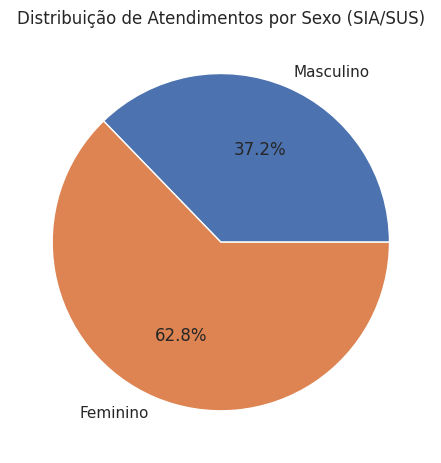

In [30]:
df_sexo = con.execute("""
    SELECT 
        CASE SEXOPAC 
            WHEN 'M' THEN 'Masculino'
            WHEN 'F' THEN 'Feminino'
            ELSE 'Não Informado'
        END as Sexo,
        COUNT(*) as Total
    FROM data
    GROUP BY 1
""").df()

plt.pie(
    df_sexo['Total'], 
    labels=df_sexo['Sexo'], 
    autopct='%1.1f%%'
)

plt.title('Distribuição de Atendimentos por Sexo (SIA/SUS)')

plt.tight_layout()
plt.show()

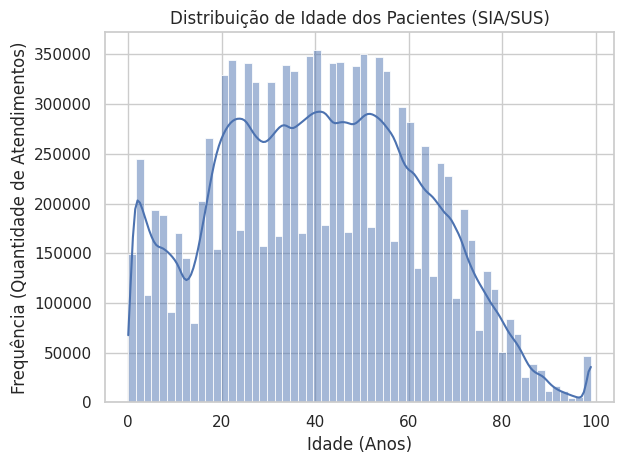

In [31]:
query = """
    SELECT TRY_CAST(IDADEPAC AS INTEGER) as idade 
    FROM data 
    WHERE IDADEPAC != '' 
      AND IDADEPAC IS NOT NULL 
      AND TRY_CAST(IDADEPAC AS INTEGER) BETWEEN 0 AND 120
"""

df_idade = con.execute(query).df()

sns.histplot(df_idade['idade'], bins=60, kde=True)

plt.title('Distribuição de Idade dos Pacientes (SIA/SUS)')
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência (Quantidade de Atendimentos)')

plt.tight_layout()
plt.show()

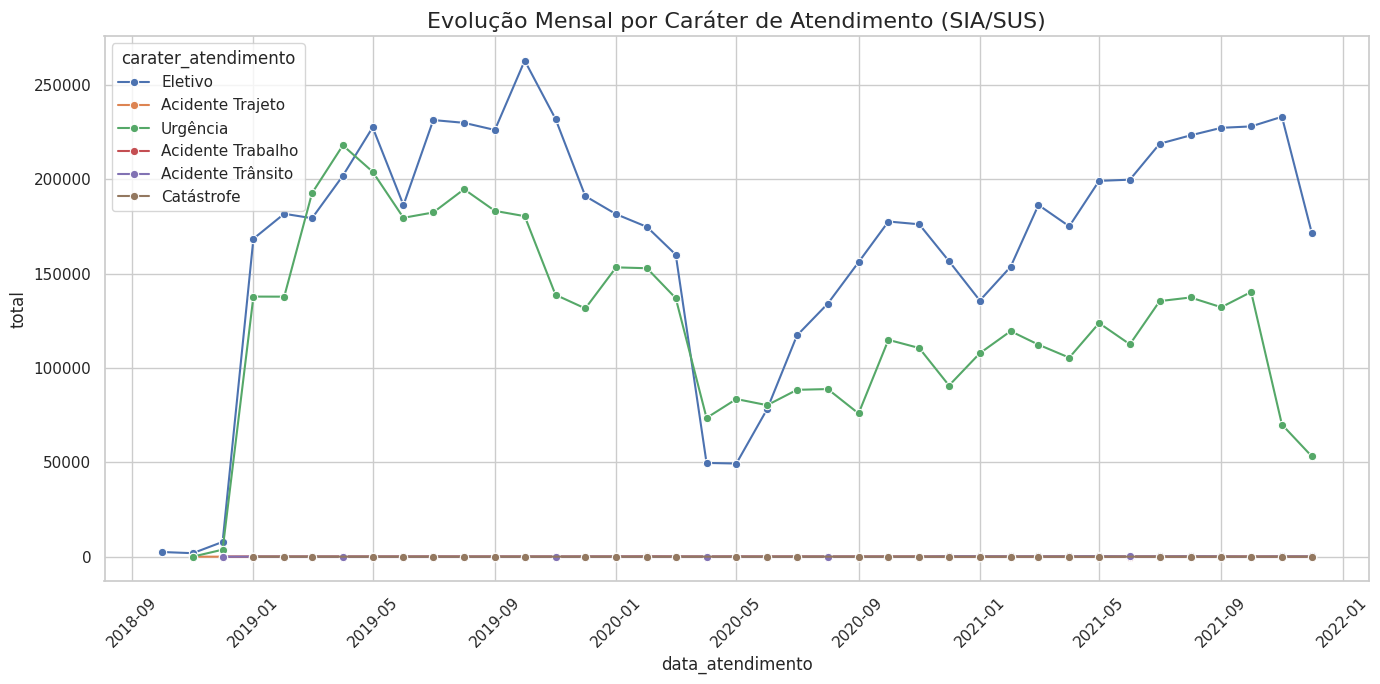

In [ ]:
query = """
SELECT 
    -- Forçamos a montagem da data: AAAAMM -> AAAA-MM-01
    CAST(SUBSTRING(TRIM(DT_ATEND), 1, 4) || '-' || SUBSTRING(TRIM(DT_ATEND), 5, 2) || '-01' AS DATE) as data_atendimento,
    CASE TRIM(CATEND)
        WHEN '01' THEN 'Eletivo'
        WHEN '02' THEN 'Urgência'
        WHEN '03' THEN 'Acidente Trabalho'
        WHEN '04' THEN 'Acidente Trajeto'
        WHEN '05' THEN 'Acidente Trânsito'
        WHEN '06' THEN 'Catástrofe'
        ELSE 'Outros/Ignorado'
    END as carater_atendimento,
    COUNT(*) as total
FROM data
WHERE LENGTH(TRIM(DT_ATEND)) = 6 -- Garante que só pegamos AAAAMM válidos
GROUP BY 1, 2
ORDER BY 1
"""

df_temporal = con.execute(query).df()

sns.lineplot(
    data=df_temporal, 
    x='data_atendimento', 
    y='total', 
    hue='carater_atendimento', 
    marker='o'
)

plt.title('Evolução Mensal por Caráter de Atendimento (SIA/SUS)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()